# Big Data and AI in Renewable Energy Systems
## Workshop 1 Notebook: Solar Power Prediction for Beginners

This notebook is designed for students with little or no prior machine learning experience.

### What you will do
- load two simple datasets - one for generated power and one for weather data
- explore and visualize the data
- train a very simple ML model
- compare real and predicted solar power values
- use predictions to make a smart energy decision

### Learning idea
The goal is not to become ML experts in one session. The goal is to understand how data and AI can help manage renewable energy systems.


## 1. Import libraries

In this first step, the Python libraries that will be used throughout the notebook are imported.
* `pandas` is used for loading and manipulating tabular data.
* `numpy` is useful for numerical operations.
* `matplotlib` is used for basic visualizations.

From `scikit-learn`, we import:
* tools for splitting data,
* the machine learning model,
* and evaluation metrics.

The `RandomForestRegressor` model is selected because it can capture nonlinear relationships between PV power and weather variables while remaining relatively simple and interpretable for educational purposes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the dataset

In this step, two separate datasets are loaded:
* one containing PV power measurements,
* and another containing weather data.

In real-world energy systems, data is typically collected from multiple sources and must be combined for analysis.

The `timestamp` column is converted to a datetime format to enable time-based operations such as sorting, merging, and feature extraction.

In [18]:
BASE_URL = "https://raw.githubusercontent.com/tskaneva/bip_2026_big_data_and_ai_in_res/main/data"

# Load PV data
pv_df = pd.read_csv( f"{BASE_URL}/sample_pv_data.csv")

# Load weather data
weather_df = pd.read_csv(f"{BASE_URL}/sample_weather_data.csv")

# Convert timestamps
pv_df['timestamp'] = pd.to_datetime(pv_df['timestamp'])
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])

pv_df.head()

,timestamp,load,generated_power
0,2024-01-01 00:00:00,2.421,0.098
1,2024-01-01 01:00:00,2.490,0.000
2,2024-01-01 02:00:00,2.299,0.007
3,2024-01-01 03:00:00,2.128,0.000
4,2024-01-01 04:00:00,2.100,0.081


### 3. Merge the two datasets into one

In this step, the PV and weather datasets are merged into a single table using the `timestamp` column.

Machine learning models require all input variables to be present in one dataset. Since PV generation depends on weather conditions, combining these datasets is essential.

An inner join is used to retain only the timestamps that exist in both datasets. This ensures that each row contains complete information for both PV production and weather variables.

The dataset is then sorted chronologically, which is necessary for time series analysis.

In [19]:
# Merge PV and weather data on timestamp
df = pd.merge(pv_df, weather_df, on='timestamp', how='inner')

# Sort chronologically
df = df.sort_values('timestamp').reset_index(drop=True)

print("Merged dataset shape:", df.shape)
display(df.head())

Merged dataset shape: (2884, 7)


,timestamp,load,generated_power,temperature,humidity,wind_speed,solar_radiation
0,2024-01-01 00:00:00,2.421,0.098,3.160,70.852,2.358,586.69
1,2024-01-01 01:00:00,2.490,0.000,1.052,78.498,2.174,789.87
2,2024-01-01 02:00:00,2.299,0.007,1.432,82.185,5.112,248.06
3,2024-01-01 03:00:00,2.128,0.000,1.972,80.542,3.040,453.30
4,2024-01-01 04:00:00,2.100,0.081,-2.156,86.385,3.315,5.84


### 4. Inspect the dataset and check for missing values
In this step, the structure and quality of the dataset are examined.

The following aspects are checked:
* data types of each column,
* overall dataset structure,
* number of missing values per column.

Missing values are common in real-world datasets due to sensor errors or communication issues. Identifying them is an essential step before applying any machine learning model.

In [20]:
print("Dataset information:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2884 entries, 0 to 2883
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        2884 non-null   datetime64[us]
 1   load             2884 non-null   float64       
 2   generated_power  2884 non-null   float64       
 3   temperature      2864 non-null   float64       
 4   humidity         2858 non-null   float64       
 5   wind_speed       2869 non-null   float64       
 6   solar_radiation  2843 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 157.8 KB
None

Missing values per column:
timestamp           0
load                0
generated_power     0
temperature        20
humidity           26
wind_speed         15
solar_radiation    41
dtype: int64


### 5. Clean missing values
In this step, missing values are handled to ensure that the dataset is suitable for model training.
1. A forward fill method is applied first, where missing values are replaced with the last available observation. This approach is commonly used in time series data when changes between consecutive timestamps are relatively small.
2. A backward fill method is then applied to handle any remaining missing values at the beginning of the dataset.
3. Finally, any remaining missing values are removed. This ensures that the dataset contains only complete records.

In [21]:
# Fill missing values using neighboring time steps
df = df.ffill()
df = df.bfill()

# Drop any remaining missing values
df = df.dropna()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
timestamp          0
load               0
generated_power    0
temperature        0
humidity           0
wind_speed         0
solar_radiation    0
dtype: int64


### 6. Create time-based features
In this step, new features are extracted from the timestamp.
The following features are created:
* `hour` - represents the time of day and is strongly related to solar generation,
* `day_of_week` - may capture weekly patterns,
* `month`  captures seasonal variations.

These features help the model learn patterns related to time, which are important in renewable energy forecasting.

In [22]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

display(df[['timestamp', 'hour', 'day_of_week', 'month']].head())

,timestamp,hour,day_of_week,month
0,2024-01-01 00:00:00,0,0,1
1,2024-01-01 01:00:00,1,0,1
2,2024-01-01 02:00:00,2,0,1
3,2024-01-01 03:00:00,3,0,1
4,2024-01-01 04:00:00,4,0,1


### 7. Create the target for hour-ahead prediction
In this step, the prediction target is defined for an hour-ahead forecasting task.
The goal is to predict PV power at the next time step (one hour ahead) using current information.
This is achieved by shifting the PV power column by one step forward. As a result:
1. the current row contains input features,
2. the target corresponds to the next hour.
The last row is removed because it does not have a future value available.

In [23]:
# Create the target variable: PV power one hour ahead
df['target_power'] = df['generated_power'].shift(-1)

# Remove the last row because it has no future target
df = df.dropna().reset_index(drop=True)

display(df[['timestamp', 'generated_power', 'target_power']].head())

,timestamp,generated_power,target_power
0,2024-01-01 00:00:00,0.098,0.000
1,2024-01-01 01:00:00,0.000,0.007
2,2024-01-01 02:00:00,0.007,0.000
3,2024-01-01 03:00:00,0.000,0.081
4,2024-01-01 04:00:00,0.081,0.000


### 8. Explore the data visually
In this step, a portion of the PV power data is visualized over time.
This visualization helps to observe:
* daily generation patterns,
* periods of zero production (e.g., nighttime),
* variability due to weather conditions.
Visual inspection of the data is useful for understanding underlying patterns before applying machine learning models.

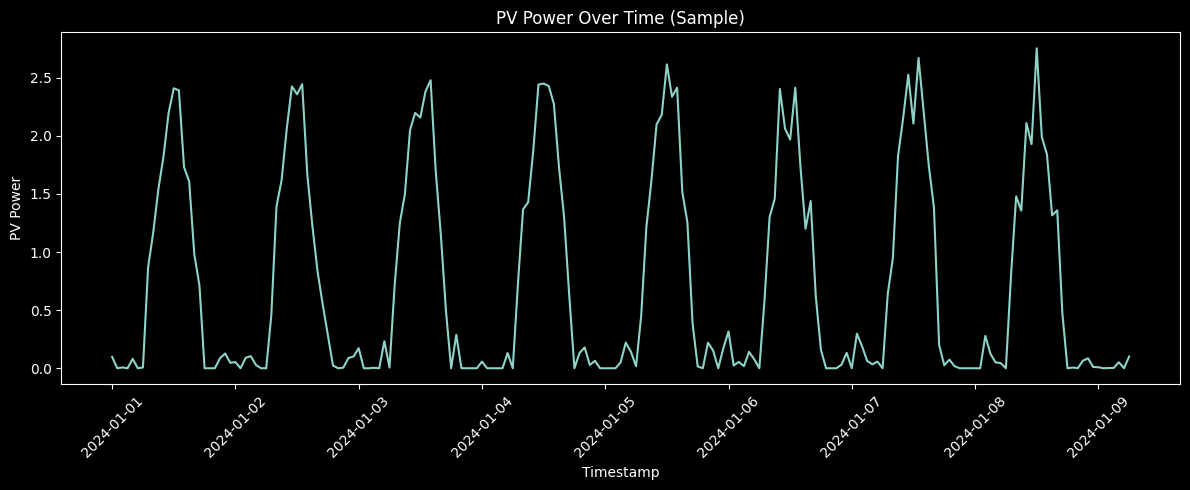

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(df['timestamp'][:200], df['generated_power'][:200])
plt.title("PV Power Over Time (Sample)")
plt.xlabel("Timestamp")
plt.ylabel("PV Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9. Select the input features and target
In this step, the input features (`X`) and the target variable (`y`) are defined.
The selected features include:
* current PV power,
* solar radiance,
* temperature,
* humidity,
* time-based features such as hour and month.
These variables are chosen because they are known to influence solar power generation.
The target variable is the PV power at the next time step, representing the hour-ahead forecast.

In [26]:
features = ['generated_power', 'solar_radiation', 'temperature', 'humidity', 'hour', 'month']

X = df[features]
y = df['target_power']

print("Selected features:")
print(features)

Selected features:
['generated_power', 'solar_radiation', 'temperature', 'humidity', 'hour', 'month']


### 10. Split the data into training and testing sets
In this step, the dataset is divided into training and testing subsets.
A chronological split is used instead of a random split. This is important in time series problems because future data must not be used to predict past values.
Typically:
* the first 80% of the data is used for training,
* the remaining 20% is used for testing.
This approach better reflects real-world forecasting scenarios.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 2306
Testing samples: 577


### 11. Train the Random Forest model
In this step, the machine learning model is trained using the training dataset.
The Random Forest Regressor is an ensemble model that combines multiple decision trees. It is well-suited for tabular data and can model nonlinear relationships between variables.

The following parameters are used:
* `n_estimators=100` - defines the number of trees in the forest. A higher number generally improves performance but increases computational cost.
* `max_depth=10` - limits the depth of each tree, helping to prevent overfitting.
* `random_state=42` - ensures reproducibility of results.

These parameter values provide a good balance between performance and simplicity.

In [28]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### 12. Make predictions on the test set
In this step, the trained model is used to generate predictions on the test dataset.

These predictions represent the estimated PV power one hour ahead and will be compared with the actual values to evaluate model performance.

In [29]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[1.6356664  2.70649093 0.05870674 0.69644024 2.26409757 0.74539681
 0.08164731 0.0382905  1.88895701 0.07552897]


### 13. Evaluate the model performance
In this step, the performance of the model is evaluated using two common regression metrics:

* Mean Absolute Error (MAE) - Measures the average absolute difference between predicted and actual values.
* Root Mean Squared Error (RMSE) - Measures the square root of the average squared differences and penalizes larger errors more strongly.
* R2

These metrics provide insight into how accurately the model predicts PV power.

In [30]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE  = {mae:.4f}')
print(f'RMSE = {rmse:.4f}')
print(f'R²   = {r2:.4f}')


MAE  = 0.1326
RMSE = 0.2071
R²   = 0.9659


### 14. Visualize actual vs predicted values
In this step, the predicted values are compared with the actual values using a plot.

This visualization helps to assess:
* how well the model follows the overall trend,
* how accurately peaks and drops are captured,
* where significant prediction errors occur.

Plotting a subset of the data improves readability.

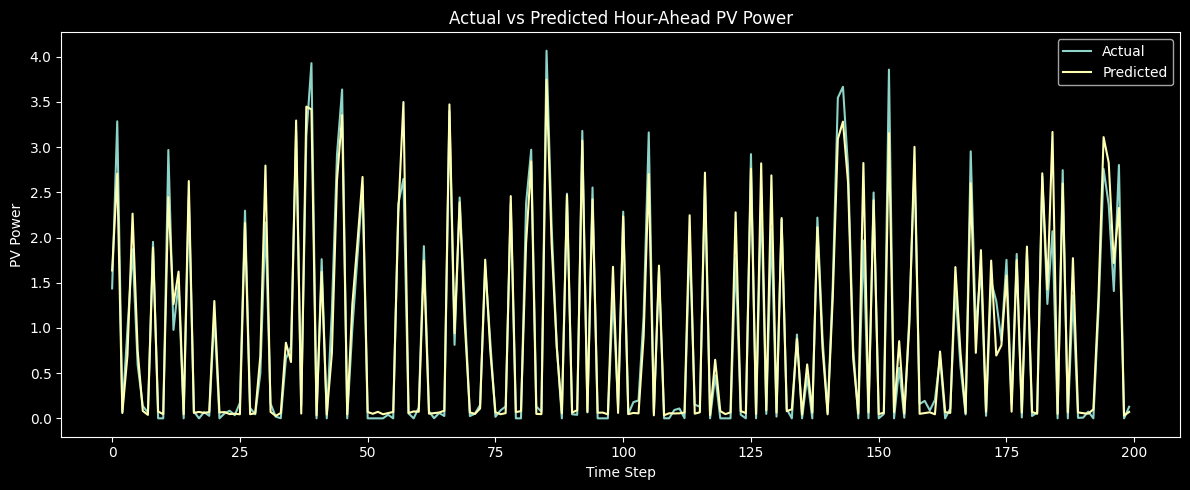

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.title("Actual vs Predicted Hour-Ahead PV Power")
plt.xlabel("Time Step")
plt.ylabel("PV Power")
plt.legend()
plt.tight_layout()
plt.show()

### 15. Analyze feature importance
In this step, the importance of each input feature is analyzed.

The Random Forest model provides an estimate of how much each feature contributes to the prediction.

This analysis helps to:
* identify the most influential variables,
* understand the relationship between inputs and PV power,
* validate domain knowledge (e.g., the importance of irradiance).

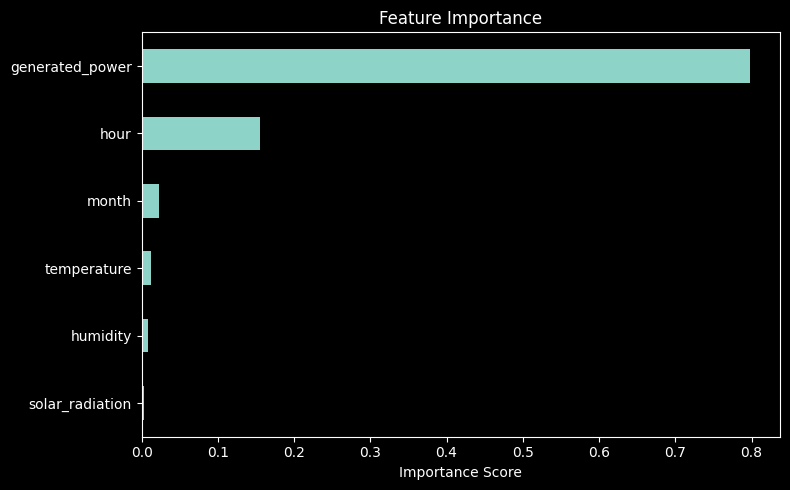

In [32]:
feature_importance = pd.Series(model.feature_importances_, index=features)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()